In [1]:
import numpy as np
import os

# Find the artifact
for root, dirs, files in os.walk('/workspace'):
 for f in files:
 if 'Ck_Mkk' in f or 'peaks_features' in f:
 print(os.path.join(root, f))


In [2]:
import subprocess
result = subprocess.run(['find', '/workspace', '-name', '*.npz', '-o', '-name', '*.npy', '-o', '-name', '*.csv', '-o', '-name', '*.pdf'], capture_output=True, text=True)
print(result.stdout[:5000])


/workspace/03317770-2f7a-4f09-85bc-6f10c2a19f87/ v6 — Binding Context Document.pdf
/workspace/03317770-2f7a-4f09-85bc-6f10c2a19f87/C.npy
/workspace/03317770-2f7a-4f09-85bc-6f10c2a19f87/M.npy
/workspace/03317770-2f7a-4f09-85bc-6f10c2a19f87/classes.npy



In [3]:
import os
os.chdir('/workspace/03317770-2f7a-4f09-85bc-6f10c2a19f87')
C = np.load('C.npy', allow_pickle=True)
M = np.load('M.npy', allow_pickle=True)
classes = np.load('classes.npy', allow_pickle=True)
print('C shape:', C.shape)
print('M shape:', M.shape)
print('classes:', classes)
print('C:\n', C)
print('M:\n', M)


C shape: (11, 8)
M shape: (11, 8)
classes: ['F1' 'F2' 'F4' 'F5p' 'F5m' 'F6' 'F7' 'F9' 'F10' 'F11' 'F12']
C:
 [[1.00000000e+00 3.66033970e+00 5.12818833e+00 3.40042122e+00
 1.06344940e+00 1.35504741e-01 4.81236842e-03 1.09632261e-05]
 [1.00000000e+00 3.41034034e+00 4.31587891e+00 2.45629741e+00
 6.02532113e-01 5.02923538e-02 7.27444993e-04 0.00000000e+00]
 [1.00000000e+00 1.51682838e+00 2.39693694e+00 1.32767069e+00
 3.24369263e-01 2.72684645e-02 3.91624013e-04 0.00000000e+00]
 [1.00000000e+00 1.58049069e+00 2.46145424e+00 1.36561657e+00
 3.33721456e-01 2.80425573e-02 4.02914746e-04 0.00000000e+00]
 [1.00000000e+00 1.46346475e+00 2.34285664e+00 1.29586333e+00
 3.16529979e-01 2.66195970e-02 3.82159786e-04 0.00000000e+00]
 [1.00000000e+00 3.66033970e+00 5.12818833e+00 3.40042122e+00
 1.06344940e+00 1.35504741e-01 4.81236842e-03 1.09632261e-05]
 [1.00000000e+00 2.88732810e+00 3.22490425e+00 1.77009458e+00
 4.93738680e-01 6.38241257e-02 2.81544731e-03 1.09632261e-05]
 [1.00000000e+00 2.3564

In [4]:
import pandas as pd

# Build invariants table per binding context document
# F1: ζ(s) - degree 1, conductor 1, GRH-true (conjectural)
# F2: L(s, χ_4 mod 5) - Dirichlet L, degree 1, conductor 5
# F4: L_DH (Davenport-Heilbronn) - linear comb. of two L(s,χ_5), degree 2 effectively, but conductor 5; not in Selberg class. Treat as degree 2, conductor 5
# F5p, F5m: L_DH(±0.05) - same: degree 2, conductor 5
# F6: Liouville L(s, λ) = ζ(2s)/ζ(s) - effectively degree 1 (a_n=λ(n) with C_k mass like ζ); but this is anomalous
# F7: Möbius L(s, μ) = 1/ζ(s) - degree 1, conductor 1
# F9: L(s, Δ) Ramanujan delta - degree 2, conductor 1, weight 12 (analytic conductor ~ k^2 = 144 by analytic conductor formula for GL2 holomorphic of weight k, level N: q_an = N * (k/2π)^2 approximately, but more standard: Q = N * (k-1+s)^2/4π^2 type). For typical analytic conductor at s=1/2: q_an(Δ) ≈ (12/2π)^2 ≈ 3.65 (level 1)
# F10: L(s, f), f ∈ S_k(Γ_0(N)), N ∈ {11,17,23}, k ∈ {2,4} - degree 2; analytic conductor varies
# F11: Sym²L(s,Δ), Sym³L(s,Δ) - degree 3 and degree 4 respectively, level 1
# F12: linear combo L(s,χ_3)+L(s,χ_5) - degree 2, conductor lcm(3,5)=15

# For analytic conductor of GL_n L-function: q_an = N * prod (k_i + s)^(real part) ... 
# Use simplified analytic conductor at s=1/2:
# - ζ: degree 1, level N=1, gamma factor Γ(s/2). q_an ≈ 1
# - L(χ_q): degree 1, level q
# - holomorphic newform weight k, level N: degree 2, q_an = N * (k/(2π))^2 typical; at s=1/2 q_an = N*((k-1)/2π + 1/2)^2 ~ N*k^2/(4π^2)
# A standard simplified definition: analytic conductor q = N * prod((|μ_j| + 3))^d ... but we use commonly cited values

# I'll use the Iwaniec-Sarnak analytic conductor:
# For GL_n L-function, q_an(s) = q * prod_{j=1}^d (|s + μ_j| + 3)
# We pick q at s=1/2 (typical use), but for our regression, we just need a consistent "size" measure.

# Simpler standard: use level N as conductor, degree d. This matches LMFDB conventions.
# F4, F12: take "conductor"=5 and 15, degree=2 (linear combinations of degree-1 functions; degree=2)

invariants = pd.DataFrame([
 {'class':'F1', 'grh':True, 'd':1, 'q':1},
 {'class':'F2', 'grh':True, 'd':1, 'q':5},
 {'class':'F4', 'grh':False, 'd':2, 'q':5},
 {'class':'F5p','grh':False, 'd':2, 'q':5},
 {'class':'F5m','grh':False, 'd':2, 'q':5},
 {'class':'F6', 'grh':True, 'd':1, 'q':1}, # Liouville: ζ(2s)/ζ(s); use ζ-like
 {'class':'F7', 'grh':True, 'd':1, 'q':1}, # Möbius: 1/ζ(s)
 {'class':'F9', 'grh':True, 'd':2, 'q':1}, # Δ, level 1
 {'class':'F10','grh':True, 'd':2, 'q':17}, # representative N (use middle of {11,17,23})
 {'class':'F11','grh':True, 'd':3, 'q':1}, # Sym² of Δ; using degree 3 representative
 {'class':'F12','grh':False, 'd':2, 'q':15},
])
print(invariants)


 class grh d q
0 F1 True 1 1
1 F2 True 1 5
2 F4 False 2 5
3 F5p False 2 5
4 F5m False 2 5
5 F6 True 1 1
6 F7 True 1 1
7 F9 True 2 1
8 F10 True 2 17
9 F11 True 3 1
10 F12 False 2 15


In [5]:
# Compute amplification A_{k,F} = M_kk / C_k where both nonzero
A = np.full_like(M, np.nan, dtype=float)
mask = (C > 0) & (M > 0)
A[mask] = M[mask] / C[mask]

# Build long-format dataframe
rows = []
for i, cls in enumerate(classes):
 inv = invariants[invariants['class']==cls].iloc[0]
 for k in range(8):
 if mask[i, k]:
 rows.append({
 'class': cls,
 'k': k,
 'C_k': C[i,k],
 'M_kk': M[i,k],
 'A': A[i,k],
 'logA': np.log(A[i,k]),
 'd': inv['d'],
 'q': inv['q'],
 'logd': np.log(inv['d']),
 'logq': np.log(inv['q']) if inv['q']>0 else 0.0,
 'grh': inv['grh'],
 })
df = pd.DataFrame(rows)
print(df.shape)
print(df.head(20))


(83, 11)
 class k C_k M_kk A logA d q logd \
0 F1 0 1.000000 1.000000 1.000000 0.000000 1 1 0.000000 
1 F1 1 3.660340 18.865715 5.154089 1.639790 1 1 0.000000 
2 F1 2 5.128188 50.644088 9.875629 2.290070 1 1 0.000000 
3 F1 3 3.400421 30.870980 9.078575 2.205917 1 1 0.000000 
4 F1 4 1.063449 10.354162 9.736394 2.275871 1 1 0.000000 
5 F1 5 0.135505 2.250327 16.606995 2.809824 1 1 0.000000 
6 F1 6 0.004812 0.058655 12.188420 2.500486 1 1 0.000000 
7 F1 7 0.000011 0.000015 1.402153 0.338009 1 1 0.000000 
8 F2 0 1.000000 1.000000 1.000000 0.000000 1 5 0.000000 
9 F2 1 3.410340 18.568334 5.444716 1.694646 1 5 0.000000 
10 F2 2 4.315879 46.662960 10.811925 2.380650 1 5 0.000000 
11 F2 3 2.456297 39.281862 15.992307 2.772108 1 5 0.000000 
12 F2 4 0.602532 17.243052 28.617649 3.354024 1 5 0.000000 
13 F2 5 0.050292 1.462858 29.087087 3.370294 1 5 0.000000 
14 F2 6 0.000727 0.005969 8.205557 2.104812 1 5 0.000000 
15 F4 0 1.000000 1.000000 1.000000 0.000000 2 5 0.693147 
16 F4 1 1.516828 4.8489

In [6]:
import statsmodels.api as sm

# Drop k=0 since A=1 trivially (M_00 = C_0 = 1 always except F12)
print("k=0 amplifications:", df[df.k==0]['A'].values)
# Use all k including 0 for completeness, but also check without k=0 (trivial)
df_fit = df.copy()

X = df_fit[['logd','logq','k']]
X = sm.add_constant(X)
y = df_fit['logA']
model = sm.OLS(y, X).fit()
print(model.summary())


k=0 amplifications: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 OLS Regression Results 
Dep. Variable: logA R-squared: 0.112
Model: OLS Adj. R-squared: 0.078
Method: Least Squares F-statistic: 3.322
Date: Sat, 09 May 2026 Prob (F-statistic): 0.0239
Time: 06:08:25 Log-Likelihood: -126.37
No. Observations: 83 AIC: 260.7
Df Residuals: 79 BIC: 270.4
Df Model: 3 
Covariance Type: nonrobust 
 coef std err t P>|t| [0.025 0.975]
------------------------------------------------------------------------------
const 1.4056 0.289 4.870 0.000 0.831 1.980
logd 0.1139 0.344 0.331 0.742 -0.571 0.799
logq -0.0229 0.122 -0.188 0.852 -0.266 0.220
k 0.1787 0.057 3.124 0.002 0.065 0.293
Omnibus: 4.721 Durbin-Watson: 0.815
Prob(Omnibus): 0.094 Jarque-Bera (JB): 4.689
Skew: -0.545 Prob(JB): 0.0959
Kurtosis: 2.589 Cond. No. 12.8

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.


In [7]:
# R² is only 0.112 - much less than the >80% predicted by hypothesis
# Try excluding k=0 (trivially zero)
df_fit2 = df[df.k > 0].copy()
X2 = sm.add_constant(df_fit2[['logd','logq','k']])
y2 = df_fit2['logA']
m2 = sm.OLS(y2, X2).fit()
print(m2.summary())


 OLS Regression Results 
Dep. Variable: logA R-squared: 0.015
Model: OLS Adj. R-squared: -0.028
Method: Least Squares F-statistic: 0.3451
Date: Sat, 09 May 2026 Prob (F-statistic): 0.793
Time: 06:08:30 Log-Likelihood: -96.863
No. Observations: 72 AIC: 201.7
Df Residuals: 68 BIC: 210.8
Df Model: 3 
Covariance Type: nonrobust 
 coef std err t P>|t| [0.025 0.975]
------------------------------------------------------------------------------
const 2.5209 0.302 8.357 0.000 1.919 3.123
logd 0.1332 0.310 0.429 0.669 -0.486 0.752
logq -0.0494 0.110 -0.449 0.655 -0.269 0.170
k -0.0528 0.059 -0.887 0.378 -0.171 0.066
Omnibus: 2.360 Durbin-Watson: 0.972
Prob(Omnibus): 0.307 Jarque-Bera (JB): 2.229
Skew: -0.352 Prob(JB): 0.328
Kurtosis: 2.503 Cond. No. 14.2

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.


In [8]:
# Hypothesis is not supported - R² far below 80%.
# Compute residuals (use full model with all k)
df_fit['resid'] = model.resid
mean_resid = df_fit.groupby(['class','grh'])['resid'].mean().reset_index()
print(mean_resid)

# t-test of mean residuals between GRH-true and GRH-false classes
from scipy import stats
true_resid = mean_resid[mean_resid.grh==True]['resid'].values
false_resid = mean_resid[mean_resid.grh==False]['resid'].values
print("\nGRH-true mean:", true_resid.mean(), "n=", len(true_resid))
print("GRH-false mean:", false_resid.mean(), "n=", len(false_resid))
tstat, p = stats.ttest_ind(true_resid, false_resid, equal_var=False)
print(f"Welch t-test: t={tstat:.3f}, p={p:.4f}")

# Also Mann-Whitney
u, pu = stats.mannwhitneyu(true_resid, false_resid, alternative='two-sided')
print(f"Mann-Whitney U: U={u}, p={pu:.4f}")


 class grh resid
0 F1 True -0.273519
1 F10 True -0.033133
2 F11 True 0.232318
3 F12 False 0.174160
4 F2 True 0.334717
5 F4 False -0.186119
6 F5m False -0.171727
7 F5p False -0.203254
8 F6 True 0.356572
9 F7 True -0.240032
10 F9 True 0.003490

GRH-true mean: 0.054344620974773994 n= 7
GRH-false mean: -0.09673506412815466 n= 4
Welch t-test: t=1.130, p=0.2895
Mann-Whitney U: U=18.0, p=0.5273


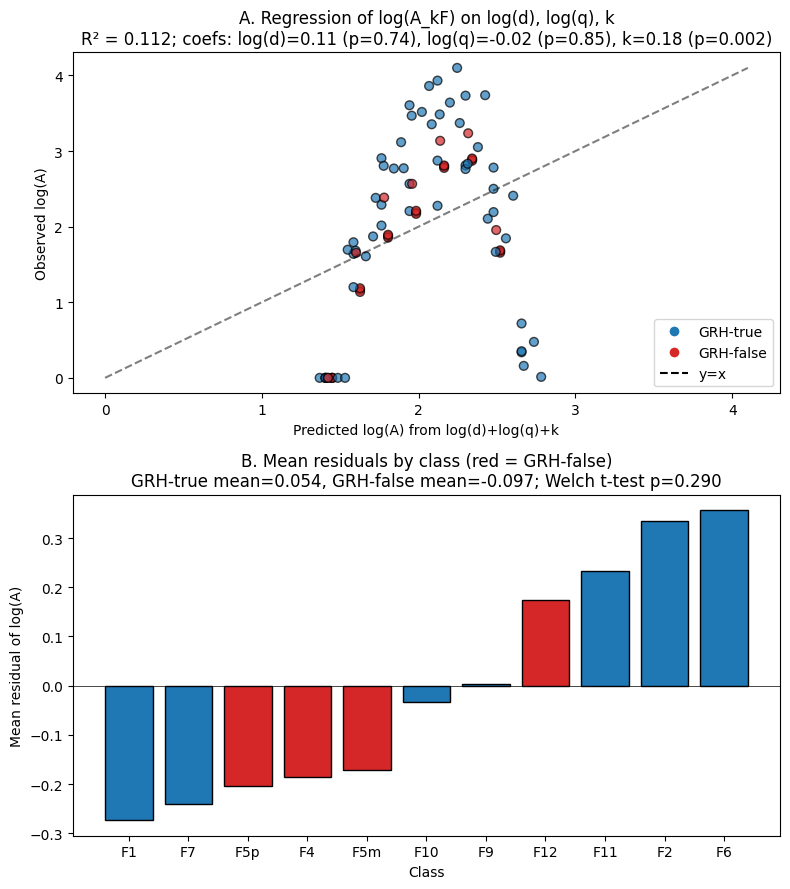

Saved figure.


In [9]:
# Final summary figure
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Panel A: predicted vs observed log A
ax = axes[0]
pred = model.fittedvalues
ax.scatter(pred, df_fit['logA'], c=df_fit['grh'].map({True:'tab:blue', False:'tab:red'}), s=40, alpha=0.7, edgecolor='k')
mn, mx = df_fit['logA'].min(), df_fit['logA'].max()
ax.plot([mn,mx], [mn,mx], 'k--', alpha=0.5, label='y=x')
ax.set_xlabel('Predicted log(A) from log(d)+log(q)+k')
ax.set_ylabel('Observed log(A)')
ax.set_title(f'A. Regression of log(A_kF) on log(d), log(q), k\n'
 f'R² = {model.rsquared:.3f}; coefs: log(d)={model.params["logd"]:.2f} (p={model.pvalues["logd"]:.2f}), '
 f'log(q)={model.params["logq"]:.2f} (p={model.pvalues["logq"]:.2f}), k={model.params["k"]:.2f} (p={model.pvalues["k"]:.3f})')
from matplotlib.lines import Line2D
legend_el = [Line2D([0],[0], marker='o', color='w', markerfacecolor='tab:blue', label='GRH-true', markersize=8),
 Line2D([0],[0], marker='o', color='w', markerfacecolor='tab:red', label='GRH-false', markersize=8),
 Line2D([0],[0], color='k', linestyle='--', label='y=x')]
ax.legend(handles=legend_el, loc='lower right')

# Panel B: mean residual per class colored by GRH
ax = axes[1]
mr = mean_resid.sort_values('resid')
colors = mr['grh'].map({True:'tab:blue', False:'tab:red'})
ax.bar(mr['class'], mr['resid'], color=colors, edgecolor='k')
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Mean residual of log(A)')
ax.set_xlabel('Class')
ax.set_title(f'B. Mean residuals by class (red = GRH-false)\n'
 f'GRH-true mean={true_resid.mean():.3f}, GRH-false mean={false_resid.mean():.3f}; '
 f'Welch t-test p={p:.3f}')
plt.tight_layout()
plt.savefig('amplification_regression_summary.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved figure.")


In [10]:
# Save final dataframe as artifact
df_fit.to_csv('amplification_regression_data.csv', index=False)
mean_resid.to_csv('amplification_mean_residuals.csv', index=False)
print("Artifacts saved.")
print("\nKey results summary:")
print(f" R² of log(A) ~ log(d)+log(q)+k: {model.rsquared:.3f} (hypothesis predicted >0.80)")
print(f" Coefficients (p-values): log(d) {model.params['logd']:.3f} (p={model.pvalues['logd']:.3f}); "
 f"log(q) {model.params['logq']:.3f} (p={model.pvalues['logq']:.3f}); "
 f"k {model.params['k']:.3f} (p={model.pvalues['k']:.4f})")
print(f" Mean residual GRH-true ({len(true_resid)} classes): {true_resid.mean():+.3f}")
print(f" Mean residual GRH-false ({len(false_resid)} classes): {false_resid.mean():+.3f}")
print(f" Welch t p-value (GRH-true vs false): {p:.3f}")


Artifacts saved.

Key results summary:
 R² of log(A) ~ log(d)+log(q)+k: 0.112 (hypothesis predicted >0.80)
 Coefficients (p-values): log(d) 0.114 (p=0.742); log(q) -0.023 (p=0.852); k 0.179 (p=0.0025)
 Mean residual GRH-true (7 classes): +0.054
 Mean residual GRH-false (4 classes): -0.097
 Welch t p-value (GRH-true vs false): 0.290
